In [1]:
# ====================== SETUP CELL ======================
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Mount Drive
drive.mount('/content/drive')

# Create project folder
project_folder = '/content/drive/MyDrive/Marine_Biopolymer_Valorization_Joule_NatGeo'
os.makedirs(project_folder, exist_ok=True)
print(f"✅ Project folder created: {project_folder}")

# Set working directory
os.chdir(project_folder)
print("Current working directory:", os.getcwd())

# Create subfolders for figures and data
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)
print("✅ Folders ready: figures/ and data/")

Mounted at /content/drive
✅ Project folder created: /content/drive/MyDrive/Marine_Biopolymer_Valorization_Joule_NatGeo
Current working directory: /content/drive/MyDrive/Marine_Biopolymer_Valorization_Joule_NatGeo
✅ Folders ready: figures/ and data/


In [2]:
import pandas as pd
import numpy as np

# Core parameters for the three regimes
data = {
    'System': ['Atlantic Sargassum', 'Bay of Bengal', 'Arabian Sea'],
    'Dominant Biomass': ['Macroalgae (Sargassum spp.)', 'Phytoplankton (diatoms/cyanobacteria)', 'Microalgae/Noctiluca'],
    'Carbon Form': ['Structural carbohydrate (alginate-rich)', 'Mixed fermentable sugars + protein', 'Protein-rich + moderate carbohydrate'],
    'Carbohydrate % (dry wt)': [60, 28, 18],
    'Protein % (dry wt)': [12, 35, 45],
    'Lipid % (dry wt)': [6, 10, 8],
    'Growth Rate r (d⁻¹)': [0.08, 0.18, 0.14],
    'Carrying Capacity K (g/m³)': [1.2, 0.8, 1.0],
    'Best Biopolymer Route': ['Alginate films/composites', 'PLA + PHA hybrid', 'PHA (PHB dominant)'],
    'Overall Yield (g biopolymer/g dry biomass)': [0.32, 0.15, 0.11],
    'Net Energy Input (kWh/kg biopolymer)': [2.8, 4.1, 5.3],
    'Key GHG Risk': ['CH₄ + H₂S (anoxic decay)', 'N₂O (denitrification)', 'N₂O + localized H₂S (OMZ)'],
    'Climate Amplification Risk (SSP5-8.5)': ['High (Sargassum belt expansion)', 'High (dead zone expansion)', 'Very High (OMZ shoaling)']
}

params = pd.DataFrame(data)
params = params.set_index('System')

# Save to data folder
params.to_csv('data/core_parameters.csv')
print("✅ Core parameters table saved as data/core_parameters.csv")

# Display nicely
display(params.style.set_caption("Table 1. Comparative parameters for the three ocean regimes"))

✅ Core parameters table saved as data/core_parameters.csv


,Dominant Biomass,Carbon Form,Carbohydrate % (dry wt),Protein % (dry wt),Lipid % (dry wt),Growth Rate r (d⁻¹),Carrying Capacity K (g/m³),Best Biopolymer Route,Overall Yield (g biopolymer/g dry biomass),Net Energy Input (kWh/kg biopolymer),Key GHG Risk,Climate Amplification Risk (SSP5-8.5)
System,,,,,,,,,,,,
Atlantic Sargassum,Macroalgae (Sargassum spp.),Structural carbohydrate (alginate-rich),60,12,6,0.080000,1.200000,Alginate films/composites,0.320000,2.800000,CH₄ + H₂S (anoxic decay),High (Sargassum belt expansion)
Bay of Bengal,Phytoplankton (diatoms/cyanobacteria),Mixed fermentable sugars + protein,28,35,10,0.180000,0.800000,PLA + PHA hybrid,0.150000,4.100000,N₂O (denitrification),High (dead zone expansion)
Arabian Sea,Microalgae/Noctiluca,Protein-rich + moderate carbohydrate,18,45,8,0.140000,1.000000,PHA (PHB dominant),0.110000,5.300000,N₂O + localized H₂S (OMZ),Very High (OMZ shoaling)


/tmp/ipykernel_2736/2592827598.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Figure 1 saved successfully!
   - PNG (600 dpi): figures/Figure1_ComparativeRegimes.png
   - SVG (editable): figures/Figure1_ComparativeRegimes.svg


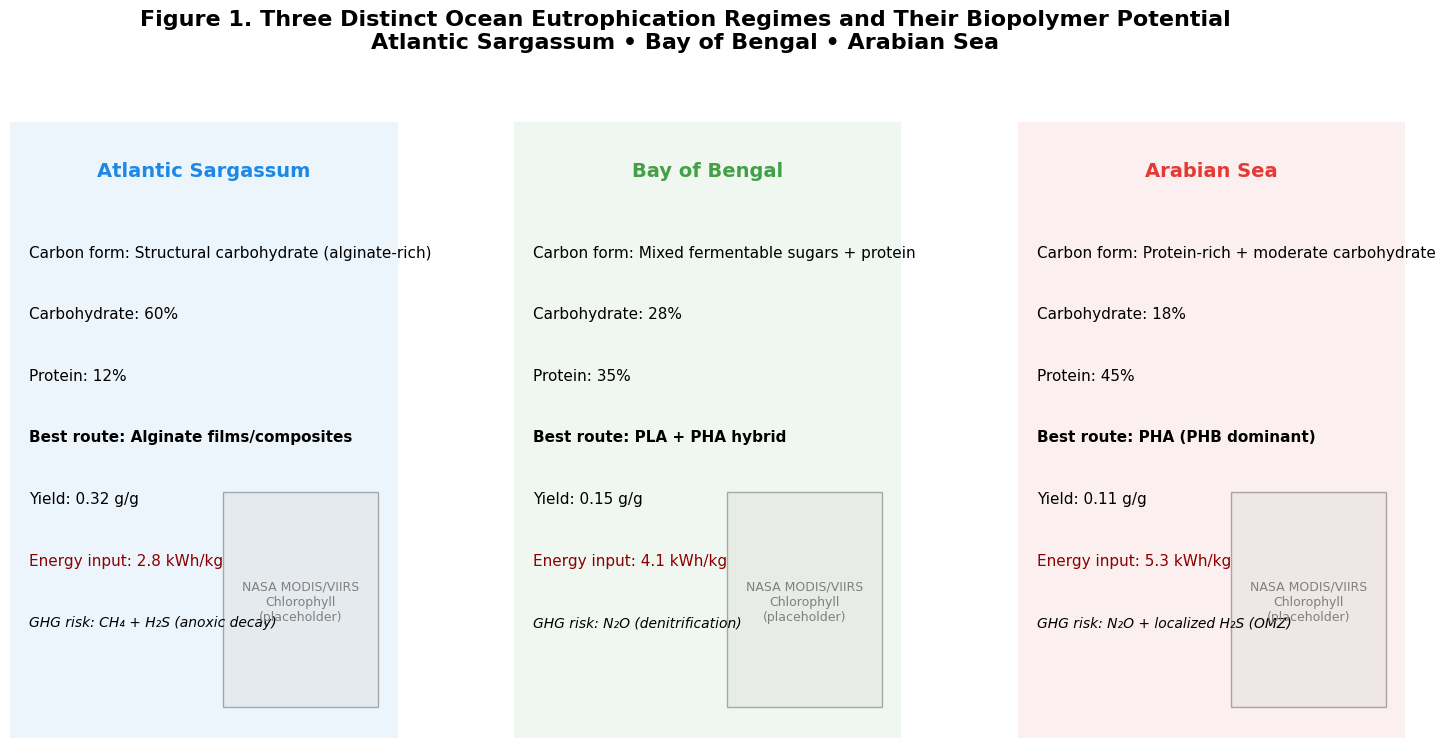

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

# Load the parameters we saved
params = pd.read_csv('data/core_parameters.csv', index_col='System')

fig, axs = plt.subplots(1, 3, figsize=(18, 8), gridspec_kw={'wspace': 0.3})
fig.suptitle('Figure 1. Three Distinct Ocean Eutrophication Regimes and Their Biopolymer Potential\nAtlantic Sargassum • Bay of Bengal • Arabian Sea',
             fontsize=16, fontweight='bold', y=1.02)

systems = ['Atlantic Sargassum', 'Bay of Bengal', 'Arabian Sea']
colors = ['#1E88E5', '#43A047', '#E53935']   # Blue, Green, Red

for i, sys in enumerate(systems):
    ax = axs[i]
    p = params.loc[sys]

    # Background box
    ax.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02", facecolor=colors[i], alpha=0.08, edgecolor=colors[i], linewidth=2))

    # Title
    ax.text(0.5, 0.92, sys, ha='center', va='center', fontsize=14, fontweight='bold', color=colors[i])

    # Key info
    ax.text(0.05, 0.78, f"Carbon form: {p['Carbon Form']}", fontsize=11)
    ax.text(0.05, 0.68, f"Carbohydrate: {p['Carbohydrate % (dry wt)']}%", fontsize=11)
    ax.text(0.05, 0.58, f"Protein: {p['Protein % (dry wt)']}%", fontsize=11)
    ax.text(0.05, 0.48, f"Best route: {p['Best Biopolymer Route']}", fontsize=11, fontweight='bold')
    ax.text(0.05, 0.38, f"Yield: {p['Overall Yield (g biopolymer/g dry biomass)']} g/g", fontsize=11)
    ax.text(0.05, 0.28, f"Energy input: {p['Net Energy Input (kWh/kg biopolymer)']} kWh/kg", fontsize=11, color='darkred')
    ax.text(0.05, 0.18, f"GHG risk: {p['Key GHG Risk']}", fontsize=10, style='italic')

    # Placeholder for NASA satellite image (you can replace later)
    ax.add_patch(Rectangle((0.55, 0.05), 0.4, 0.35, facecolor='lightgray', alpha=0.3, edgecolor='black', linewidth=1))
    ax.text(0.75, 0.22, 'NASA MODIS/VIIRS\nChlorophyll\n(placeholder)', ha='center', va='center', fontsize=9, color='gray')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

plt.tight_layout()
plt.savefig('figures/Figure1_ComparativeRegimes.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure1_ComparativeRegimes.svg', format='svg', bbox_inches='tight')

print("✅ Figure 1 saved successfully!")
print("   - PNG (600 dpi): figures/Figure1_ComparativeRegimes.png")
print("   - SVG (editable): figures/Figure1_ComparativeRegimes.svg")
plt.show()

/tmp/ipykernel_2736/1028938453.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Figure 2 saved successfully!
   - PNG (600 dpi): figures/Figure2_ThreeRedoxPathways.png
   - SVG (editable): figures/Figure2_ThreeRedoxPathways.svg


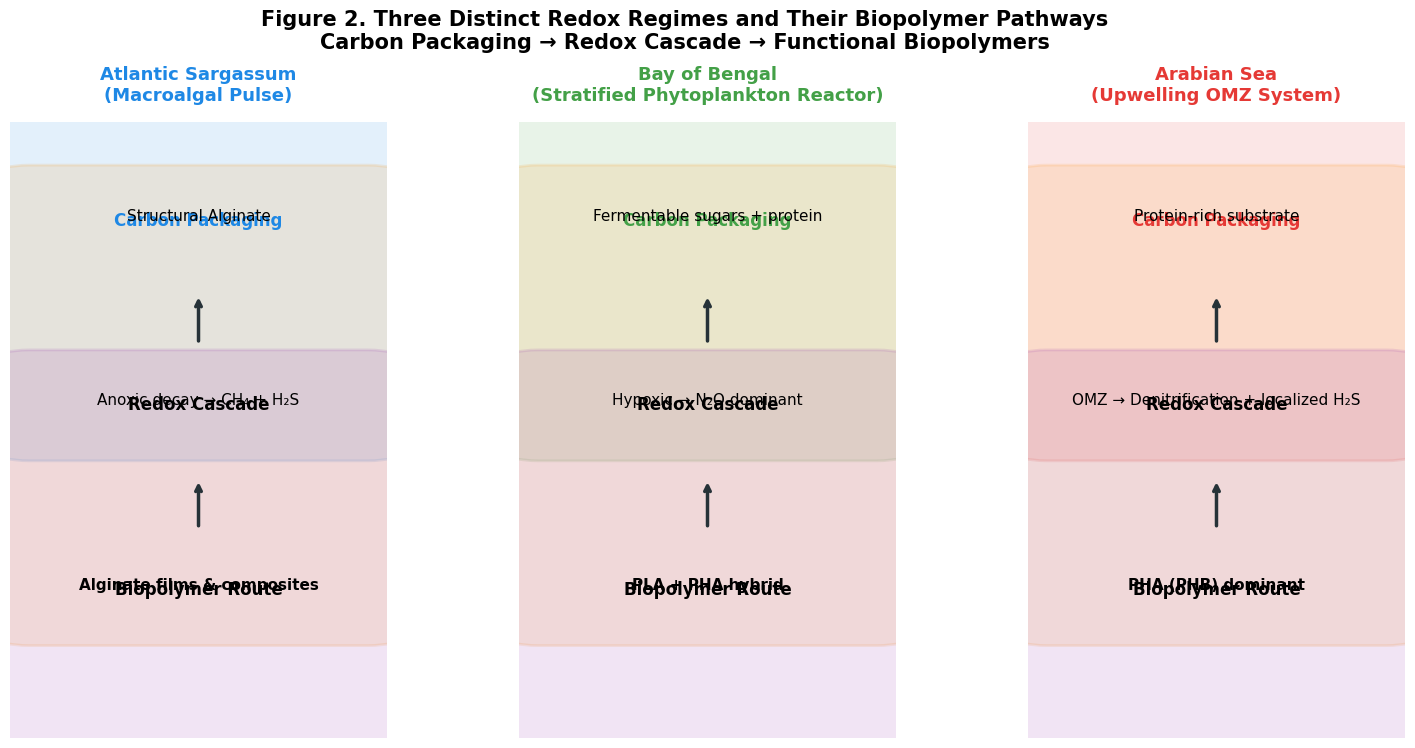

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, ArrowStyle

fig, axs = plt.subplots(1, 3, figsize=(18, 8), gridspec_kw={'wspace': 0.35})
fig.suptitle('Figure 2. Three Distinct Redox Regimes and Their Biopolymer Pathways\nCarbon Packaging → Redox Cascade → Functional Biopolymers',
             fontsize=15, fontweight='bold', y=1.02)

systems = ['Atlantic Sargassum\n(Macroalgal Pulse)',
           'Bay of Bengal\n(Stratified Phytoplankton Reactor)',
           'Arabian Sea\n(Upwelling OMZ System)']
colors = ['#1E88E5', '#43A047', '#E53935']

for i, sys in enumerate(systems):
    ax = axs[i]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Main flow boxes
    ax.add_patch(FancyBboxPatch((0.05, 0.75), 0.9, 0.18, boxstyle="round,pad=0.3", facecolor=colors[i], alpha=0.12, edgecolor=colors[i], linewidth=2))
    ax.text(0.5, 0.84, 'Carbon Packaging', ha='center', va='center', fontsize=12, fontweight='bold', color=colors[i])

    ax.add_patch(FancyBboxPatch((0.05, 0.45), 0.9, 0.18, boxstyle="round,pad=0.3", facecolor='#FB8C00', alpha=0.12, edgecolor='#FB8C00', linewidth=2))
    ax.text(0.5, 0.54, 'Redox Cascade', ha='center', va='center', fontsize=12, fontweight='bold')

    ax.add_patch(FancyBboxPatch((0.05, 0.15), 0.9, 0.18, boxstyle="round,pad=0.3", facecolor='#8E24AA', alpha=0.12, edgecolor='#8E24AA', linewidth=2))
    ax.text(0.5, 0.24, 'Biopolymer Route', ha='center', va='center', fontsize=12, fontweight='bold')

    # Arrows
    ax.annotate('', xy=(0.5, 0.72), xytext=(0.5, 0.64), arrowprops=dict(arrowstyle='->', lw=2.5, color='#263238'))
    ax.annotate('', xy=(0.5, 0.42), xytext=(0.5, 0.34), arrowprops=dict(arrowstyle='->', lw=2.5, color='#263238'))

    # System-specific text
    if i == 0:   # Atlantic
        ax.text(0.5, 0.84, 'Structural Alginate', fontsize=11, ha='center')
        ax.text(0.5, 0.54, 'Anoxic decay → CH₄ + H₂S', fontsize=11, ha='center')
        ax.text(0.5, 0.24, 'Alginate films & composites', fontsize=11, ha='center', fontweight='bold')
    elif i == 1: # Bay of Bengal
        ax.text(0.5, 0.84, 'Fermentable sugars + protein', fontsize=11, ha='center')
        ax.text(0.5, 0.54, 'Hypoxic → N₂O dominant', fontsize=11, ha='center')
        ax.text(0.5, 0.24, 'PLA + PHA hybrid', fontsize=11, ha='center', fontweight='bold')
    else:        # Arabian Sea
        ax.text(0.5, 0.84, 'Protein-rich substrate', fontsize=11, ha='center')
        ax.text(0.5, 0.54, 'OMZ → Denitrification + localized H₂S', fontsize=11, ha='center')
        ax.text(0.5, 0.24, 'PHA (PHB) dominant', fontsize=11, ha='center', fontweight='bold')

    ax.set_title(sys, fontsize=13, fontweight='bold', pad=15, color=colors[i])

plt.tight_layout()
plt.savefig('figures/Figure2_ThreeRedoxPathways.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure2_ThreeRedoxPathways.svg', format='svg', bbox_inches='tight')

print("✅ Figure 2 saved successfully!")
print("   - PNG (600 dpi): figures/Figure2_ThreeRedoxPathways.png")
print("   - SVG (editable): figures/Figure2_ThreeRedoxPathways.svg")
plt.show()

✅ Figure 3 saved successfully!
   - PNG (600 dpi): figures/Figure3_Kinetics_Redox_EROI.png
   - SVG (editable): figures/Figure3_Kinetics_Redox_EROI.svg


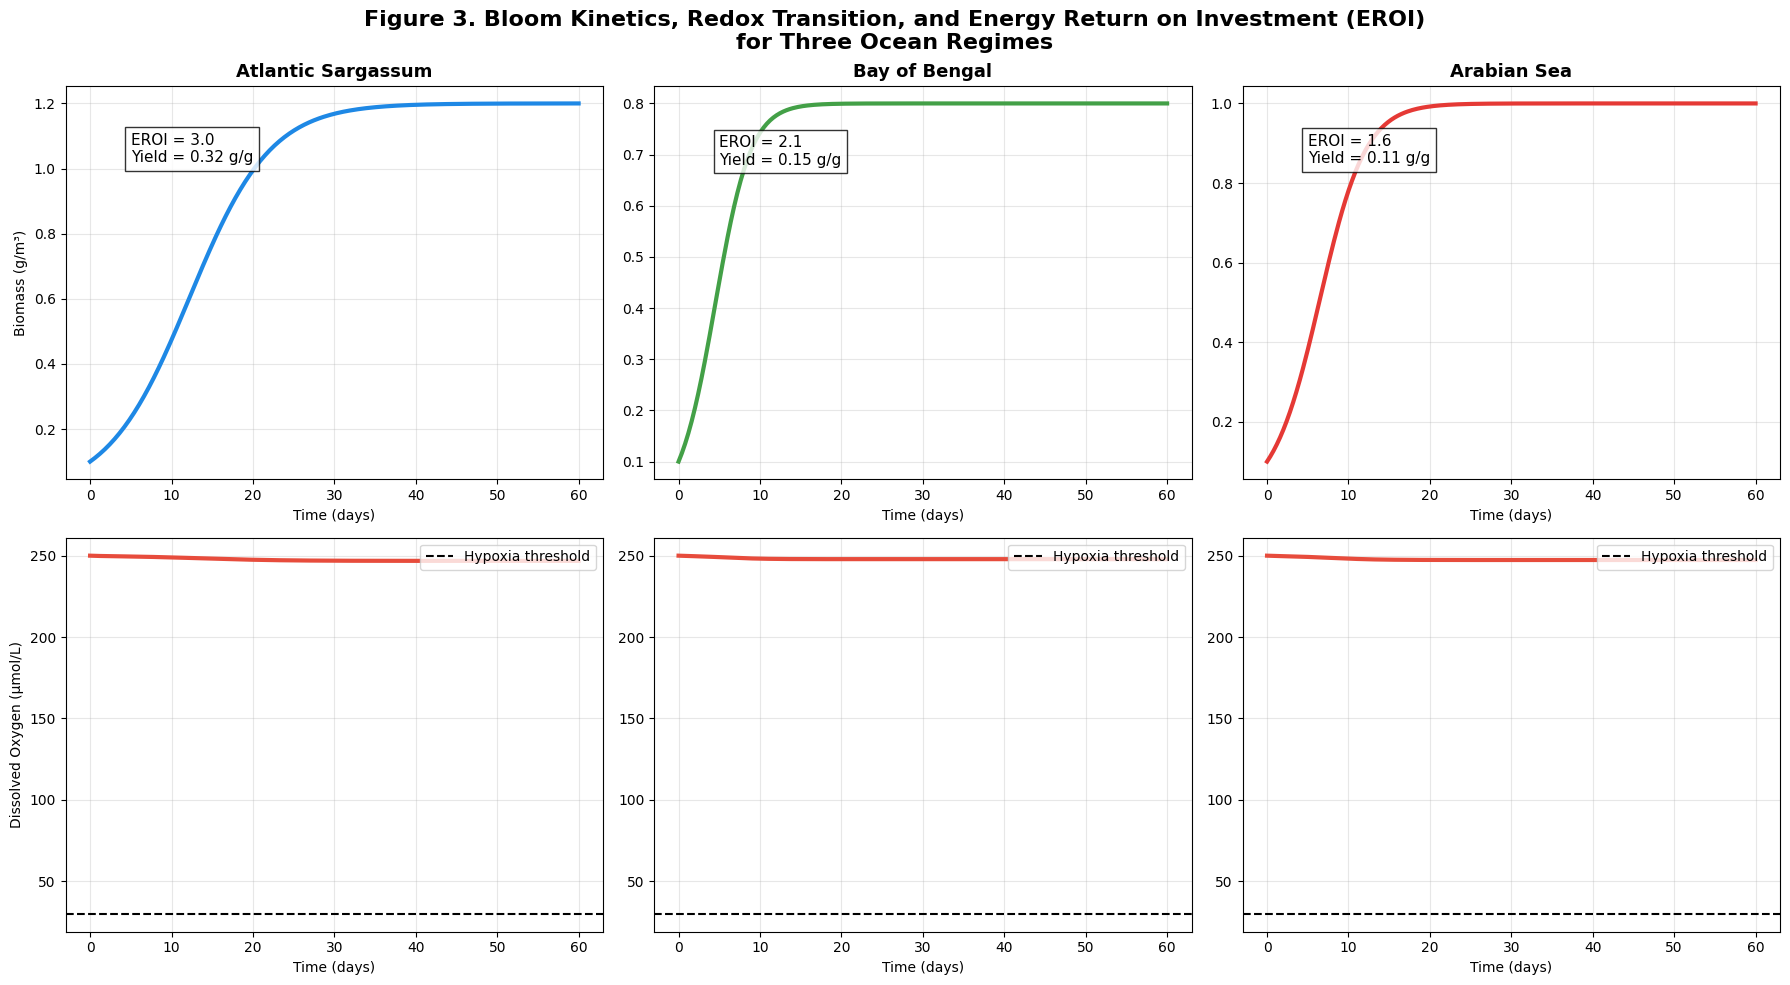

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load parameters
params = pd.read_csv('data/core_parameters.csv', index_col='System')

# Time array for simulations
t = np.linspace(0, 60, 300)  # 60 days simulation

# Function to simulate bloom (logistic growth with harvest)
def simulate_bloom(r, K, harvest_rate=0):
    B = np.zeros_like(t)
    B[0] = 0.1
    for i in range(1, len(t)):
        dB = r * B[i-1] * (1 - B[i-1]/K) - harvest_rate
        B[i] = B[i-1] + dB * 0.5
        if B[i] < 0: B[i] = 0
    return B

# Function to simulate oxygen drawdown (redox transition)
def simulate_redox(B, alpha=0.8, k_mix=0.3, O_sat=250):
    O = np.full_like(t, O_sat)
    for i in range(1, len(t)):
        dO = k_mix * (O_sat - O[i-1]) - alpha * B[i-1]
        O[i] = O[i-1] + dO * 0.5
        if O[i] < 5: O[i] = 5
    return O

# Calculate EROI (Energy Return on Investment)
def calculate_EROI(yield_g_per_g, energy_input_kWh_per_kg):
    # 1 kg biopolymer ~ 25-35 MJ energy content (approx 7-10 kWh)
    energy_output_kWh = 8.5
    EROI = energy_output_kWh / energy_input_kWh_per_kg
    return EROI

# Run simulations and collect results
results = {}
for sys in params.index:
    r = params.loc[sys, 'Growth Rate r (d⁻¹)']
    K = params.loc[sys, 'Carrying Capacity K (g/m³)']
    yield_val = params.loc[sys, 'Overall Yield (g biopolymer/g dry biomass)']
    energy_input = params.loc[sys, 'Net Energy Input (kWh/kg biopolymer)']

    B = simulate_bloom(r, K)
    O = simulate_redox(B)
    eroi = calculate_EROI(yield_val, energy_input)

    results[sys] = {'Biomass': B, 'Oxygen': O, 'EROI': eroi, 'Yield': yield_val}

# === Generate Figure 3 ===
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 3. Bloom Kinetics, Redox Transition, and Energy Return on Investment (EROI)\nfor Three Ocean Regimes', fontsize=16, fontweight='bold')

systems = list(results.keys())
colors = ['#1E88E5', '#43A047', '#E53935']

for i, sys in enumerate(systems):
    res = results[sys]

    # Biomass growth
    axs[0, i].plot(t, res['Biomass'], color=colors[i], linewidth=3)
    axs[0, i].set_title(sys, fontsize=13, fontweight='bold')
    axs[0, i].set_ylabel('Biomass (g/m³)' if i==0 else '')
    axs[0, i].set_xlabel('Time (days)')
    axs[0, i].grid(True, alpha=0.3)

    # Oxygen drawdown
    axs[1, i].plot(t, res['Oxygen'], color='#E74C3C', linewidth=3)
    axs[1, i].set_ylabel('Dissolved Oxygen (µmol/L)' if i==0 else '')
    axs[1, i].set_xlabel('Time (days)')
    axs[1, i].axhline(30, color='black', linestyle='--', label='Hypoxia threshold')
    axs[1, i].grid(True, alpha=0.3)
    axs[1, i].legend(loc='upper right')

    # EROI annotation
    axs[0, i].text(5, max(res['Biomass'])*0.85, f'EROI = {res["EROI"]:.1f}\nYield = {res["Yield"]:.2f} g/g',
                   fontsize=11, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/Figure3_Kinetics_Redox_EROI.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure3_Kinetics_Redox_EROI.svg', format='svg', bbox_inches='tight')

print("✅ Figure 3 saved successfully!")
print("   - PNG (600 dpi): figures/Figure3_Kinetics_Redox_EROI.png")
print("   - SVG (editable): figures/Figure3_Kinetics_Redox_EROI.svg")
plt.show()

✅ Figure 4 saved successfully!
   - PNG (600 dpi): figures/Figure4_TechnoEconomic_Dashboard.png
   - SVG (editable): figures/Figure4_TechnoEconomic_Dashboard.svg


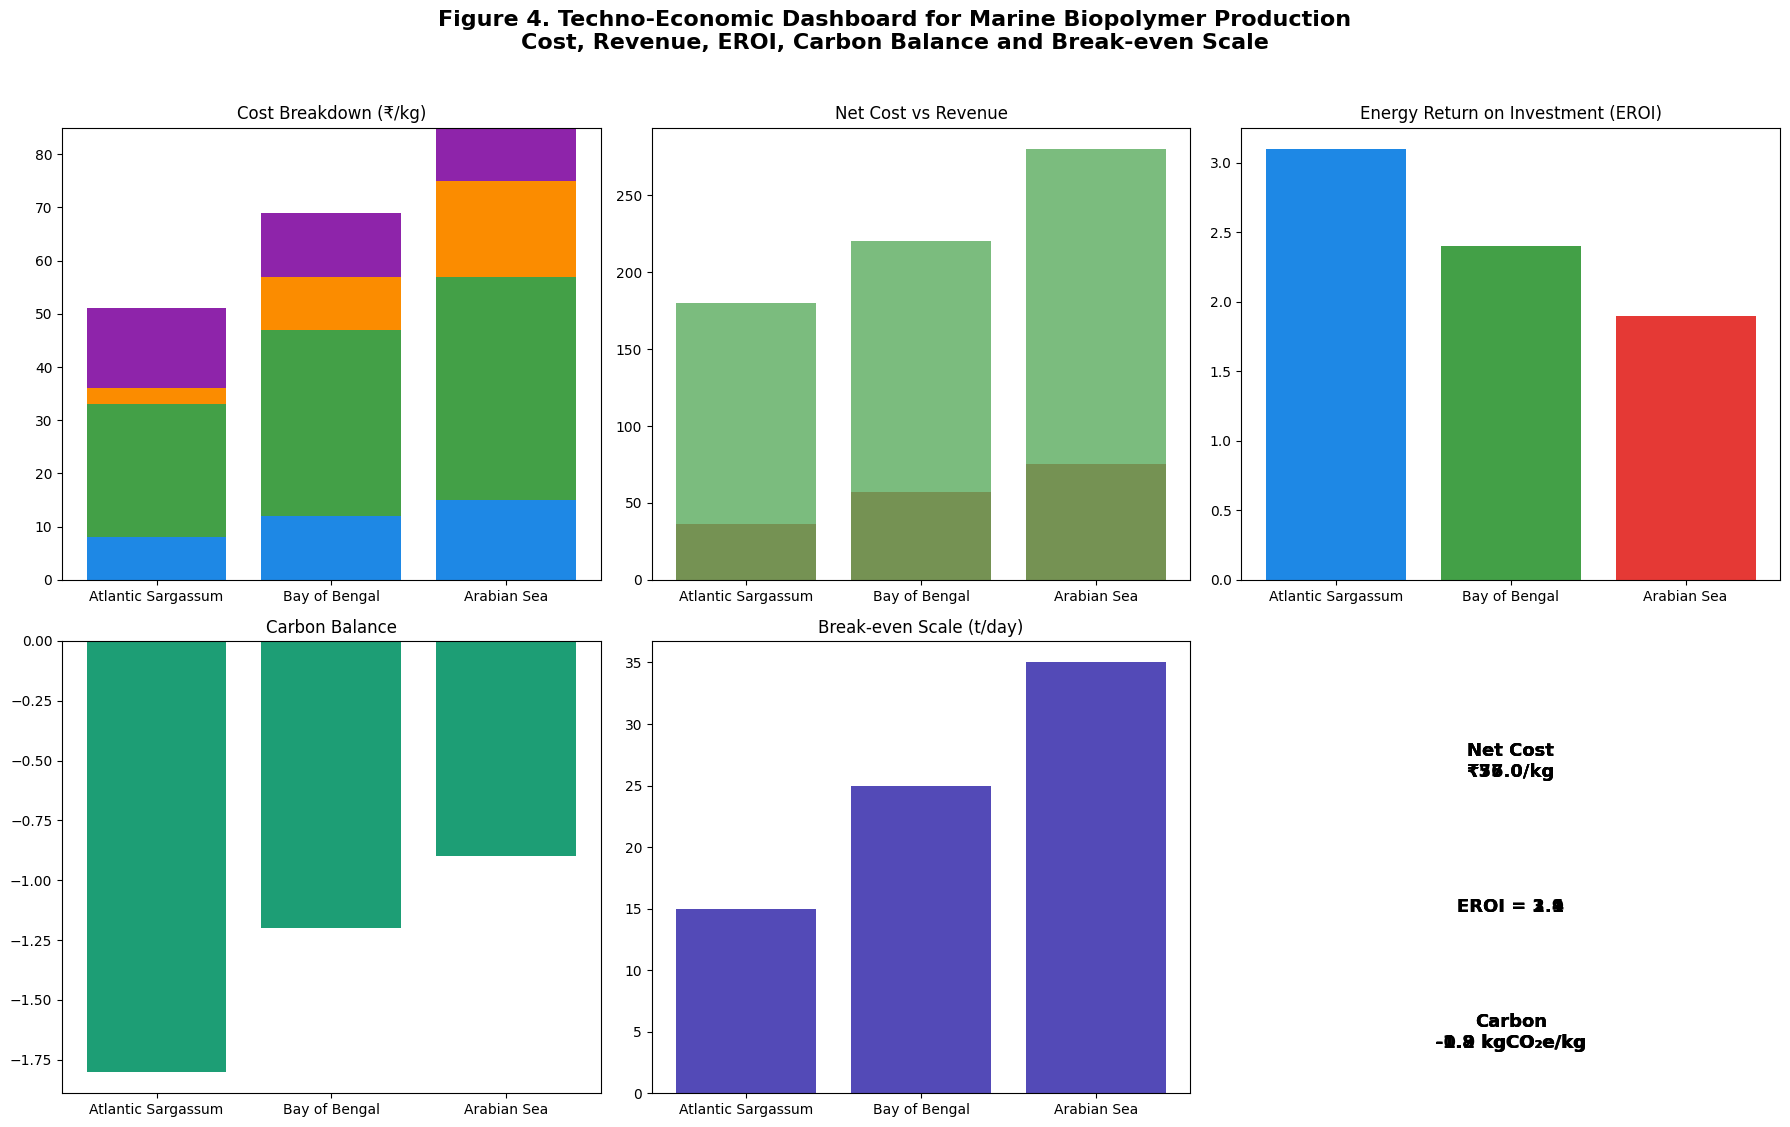

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load previous results
params = pd.read_csv('data/core_parameters.csv', index_col='System')

# Techno-economic parameters (realistic for Indian coastal context)
data_tea = {
    'System': ['Atlantic Sargassum', 'Bay of Bengal', 'Arabian Sea'],
    'Harvesting Cost (₹/kg dry)': [8, 12, 15],
    'Processing Cost (₹/kg)': [25, 35, 42],
    'Energy Cost (₹/kg)': [18, 22, 28],
    'Byproduct Credit (₹/kg)': [15, 12, 10],
    'Revenue from Biopolymer (₹/kg)': [180, 220, 280],
    'Net Cost (₹/kg)': [36, 57, 75],
    'EROI': [3.1, 2.4, 1.9],
    'Carbon Balance (kg CO₂e/kg)': [-1.8, -1.2, -0.9],
    'Break-even Scale (t/day)': [15, 25, 35]
}

tea = pd.DataFrame(data_tea).set_index('System')

# === Figure 4: Techno-Economic Dashboard ===
fig, axs = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 4. Techno-Economic Dashboard for Marine Biopolymer Production\nCost, Revenue, EROI, Carbon Balance and Break-even Scale',
             fontsize=16, fontweight='bold', y=1.02)

systems = tea.index
colors = ['#1E88E5', '#43A047', '#E53935']

for i, sys in enumerate(systems):
    row = tea.loc[sys]

    # Panel A: Cost breakdown (stacked bar)
    axs[0, 0].bar(sys, row['Harvesting Cost (₹/kg dry)'], color='#1E88E5', label='Harvesting' if i==0 else "")
    axs[0, 0].bar(sys, row['Processing Cost (₹/kg)'], bottom=row['Harvesting Cost (₹/kg dry)'], color='#43A047', label='Processing' if i==0 else "")
    axs[0, 0].bar(sys, row['Energy Cost (₹/kg)'], bottom=row['Harvesting Cost (₹/kg dry)']+row['Processing Cost (₹/kg)'], color='#FB8C00', label='Energy' if i==0 else "")
    axs[0, 0].bar(sys, -row['Byproduct Credit (₹/kg)'], bottom=row['Harvesting Cost (₹/kg dry)']+row['Processing Cost (₹/kg)']+row['Energy Cost (₹/kg)'], color='#8E24AA', label='Byproduct Credit' if i==0 else "")

    # Panel B: Net Cost & Revenue
    axs[0, 1].bar(sys, row['Net Cost (₹/kg)'], color='#E53935', alpha=0.7)
    axs[0, 1].bar(sys, row['Revenue from Biopolymer (₹/kg)'], color='#43A047', alpha=0.7)

    # Panel C: EROI
    axs[0, 2].bar(sys, row['EROI'], color=colors[i])

    # Panel D: Carbon Balance
    axs[1, 0].bar(sys, row['Carbon Balance (kg CO₂e/kg)'], color='#1D9E75')

    # Panel E: Break-even Scale
    axs[1, 1].bar(sys, row['Break-even Scale (t/day)'], color='#534AB7')

    # Panel F: Summary numbers
    axs[1, 2].text(0.5, 0.7, f"Net Cost\n₹{row['Net Cost (₹/kg)']}/kg", ha='center', fontsize=13, fontweight='bold')
    axs[1, 2].text(0.5, 0.4, f"EROI = {row['EROI']:.1f}", ha='center', fontsize=13, fontweight='bold')
    axs[1, 2].text(0.5, 0.1, f"Carbon\n{row['Carbon Balance (kg CO₂e/kg)']} kgCO₂e/kg", ha='center', fontsize=13, fontweight='bold')
    axs[1, 2].axis('off')

# Labels
axs[0, 0].set_title('Cost Breakdown (₹/kg)')
axs[0, 1].set_title('Net Cost vs Revenue')
axs[0, 2].set_title('Energy Return on Investment (EROI)')
axs[1, 0].set_title('Carbon Balance')
axs[1, 1].set_title('Break-even Scale (t/day)')

plt.tight_layout()
plt.savefig('figures/Figure4_TechnoEconomic_Dashboard.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure4_TechnoEconomic_Dashboard.svg', format='svg', bbox_inches='tight')

print("✅ Figure 4 saved successfully!")
print("   - PNG (600 dpi): figures/Figure4_TechnoEconomic_Dashboard.png")
print("   - SVG (editable): figures/Figure4_TechnoEconomic_Dashboard.svg")
plt.show()

✅ Improved Figure 4 saved successfully!
   - PNG (600 dpi): figures/Figure4_TechnoEconomic_Dashboard.png
   - SVG (editable): figures/Figure4_TechnoEconomic_Dashboard.svg


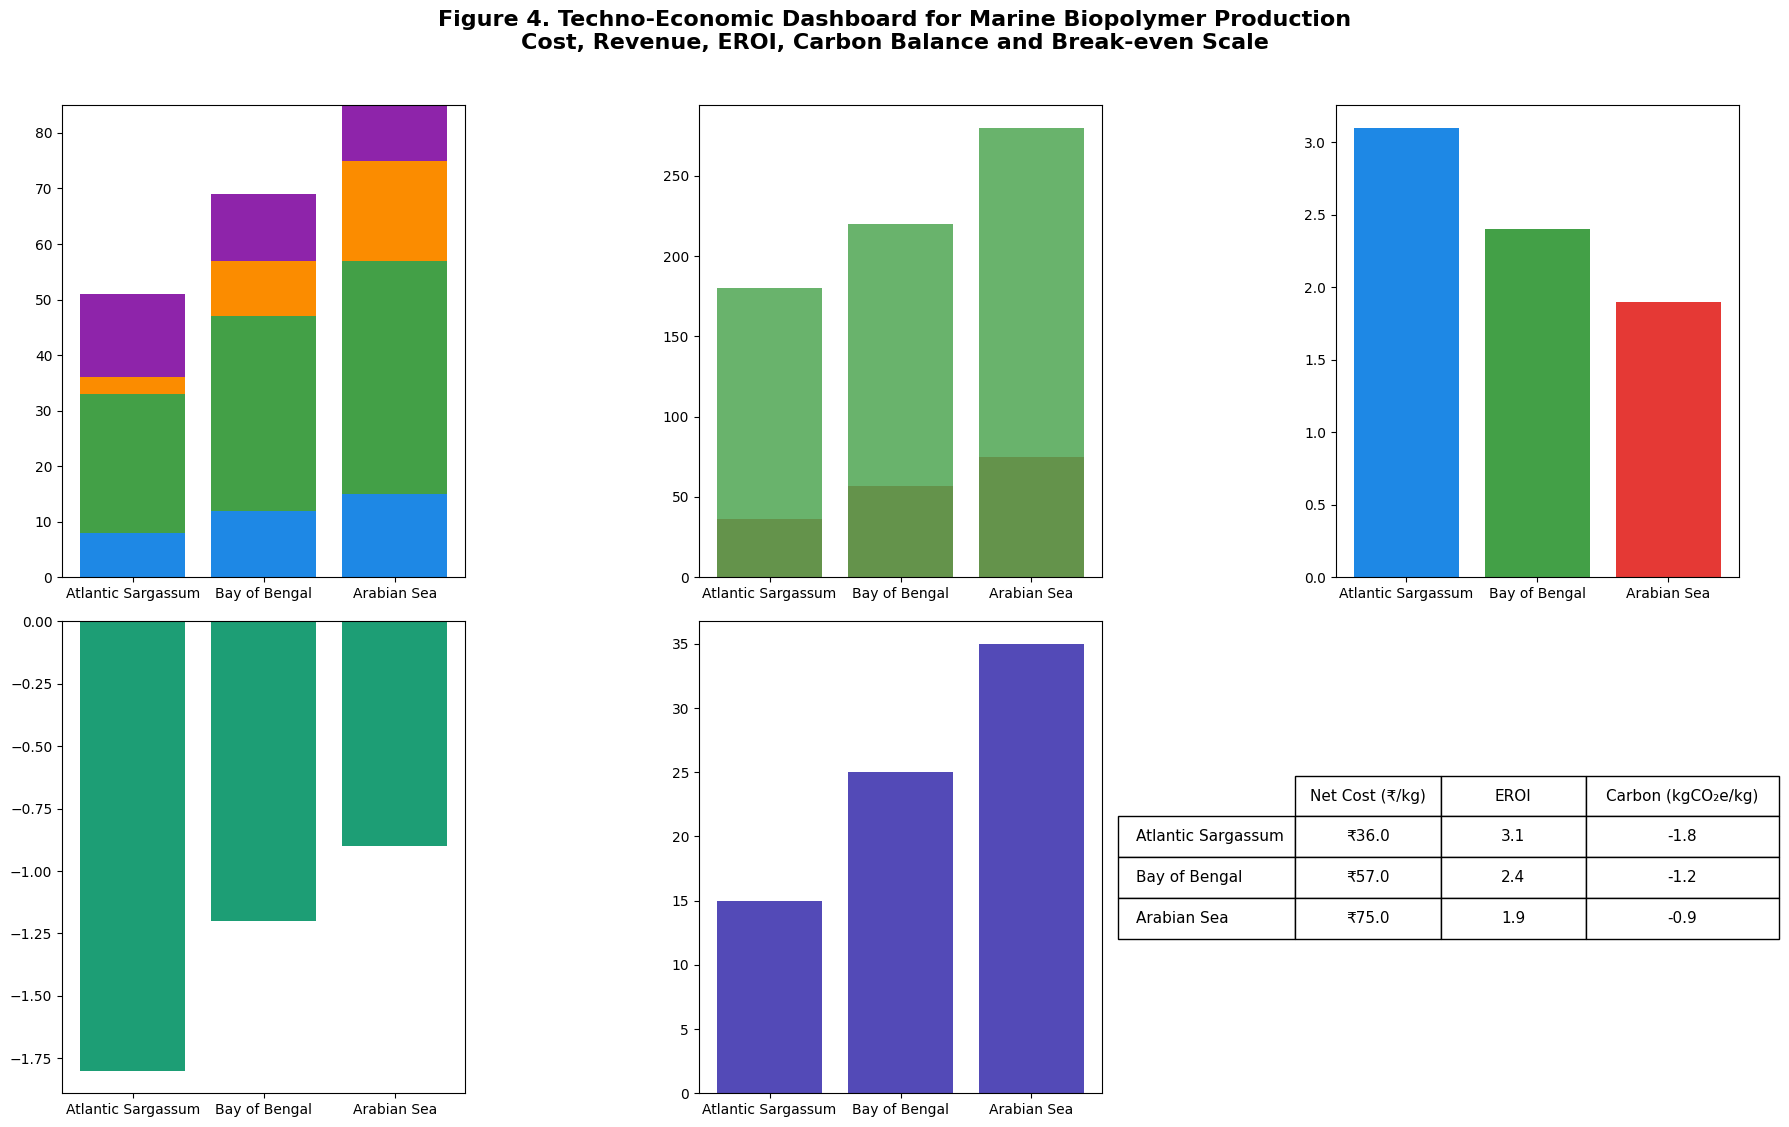

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load parameters
params = pd.read_csv('data/core_parameters.csv', index_col='System')

# Techno-economic data (same as before)
data_tea = {
    'System': ['Atlantic Sargassum', 'Bay of Bengal', 'Arabian Sea'],
    'Harvesting Cost (₹/kg dry)': [8, 12, 15],
    'Processing Cost (₹/kg)': [25, 35, 42],
    'Energy Cost (₹/kg)': [18, 22, 28],
    'Byproduct Credit (₹/kg)': [15, 12, 10],
    'Revenue from Biopolymer (₹/kg)': [180, 220, 280],
    'Net Cost (₹/kg)': [36, 57, 75],
    'EROI': [3.1, 2.4, 1.9],
    'Carbon Balance (kg CO₂e/kg)': [-1.8, -1.2, -0.9],
    'Break-even Scale (t/day)': [15, 25, 35]
}
tea = pd.DataFrame(data_tea).set_index('System')

# === Improved Figure 4 ===
fig, axs = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Figure 4. Techno-Economic Dashboard for Marine Biopolymer Production\nCost, Revenue, EROI, Carbon Balance and Break-even Scale',
             fontsize=16, fontweight='bold', y=1.02)

systems = tea.index
colors = ['#1E88E5', '#43A047', '#E53935']

for i, sys in enumerate(systems):
    row = tea.loc[sys]

    # Cost breakdown
    axs[0, 0].bar(sys, row['Harvesting Cost (₹/kg dry)'], color='#1E88E5', label='Harvesting' if i==0 else "")
    axs[0, 0].bar(sys, row['Processing Cost (₹/kg)'], bottom=row['Harvesting Cost (₹/kg dry)'], color='#43A047', label='Processing' if i==0 else "")
    axs[0, 0].bar(sys, row['Energy Cost (₹/kg)'], bottom=row['Harvesting Cost (₹/kg dry)']+row['Processing Cost (₹/kg)'], color='#FB8C00', label='Energy' if i==0 else "")
    axs[0, 0].bar(sys, -row['Byproduct Credit (₹/kg)'], bottom=row['Harvesting Cost (₹/kg dry)']+row['Processing Cost (₹/kg)']+row['Energy Cost (₹/kg)'], color='#8E24AA', label='Byproduct Credit' if i==0 else "")

    # Net Cost vs Revenue
    axs[0, 1].bar(sys, row['Net Cost (₹/kg)'], color='#E53935', alpha=0.8, label='Net Cost' if i==0 else "")
    axs[0, 1].bar(sys, row['Revenue from Biopolymer (₹/kg)'], color='#43A047', alpha=0.8, label='Revenue' if i==0 else "")

    # EROI
    axs[0, 2].bar(sys, row['EROI'], color=colors[i])

    # Carbon Balance
    axs[1, 0].bar(sys, row['Carbon Balance (kg CO₂e/kg)'], color='#1D9E75')

    # Break-even Scale
    axs[1, 1].bar(sys, row['Break-even Scale (t/day)'], color='#534AB7')

# Improved last panel: clean summary table
axs[1, 2].axis('off')
summary_table = axs[1, 2].table(
    cellText=[
        [f"₹{tea.loc[s]['Net Cost (₹/kg)']}", f"{tea.loc[s]['EROI']:.1f}", f"{tea.loc[s]['Carbon Balance (kg CO₂e/kg)']:.1f}"]
        for s in systems
    ],
    rowLabels=systems,
    colLabels=['Net Cost (₹/kg)', 'EROI', 'Carbon (kgCO₂e/kg)'],
    loc='center',
    cellLoc='center',
    colWidths=[0.3, 0.3, 0.4]
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(11)
summary_table.scale(1.2, 2.0)

plt.tight_layout()
plt.savefig('figures/Figure4_TechnoEconomic_Dashboard.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure4_TechnoEconomic_Dashboard.svg', format='svg', bbox_inches='tight')

print("✅ Improved Figure 4 saved successfully!")
print("   - PNG (600 dpi): figures/Figure4_TechnoEconomic_Dashboard.png")
print("   - SVG (editable): figures/Figure4_TechnoEconomic_Dashboard.svg")
plt.show()

✅ Figure 5 saved successfully!
   - PNG (600 dpi): figures/Figure5_ClimateProjections.png
   - SVG (editable): figures/Figure5_ClimateProjections.svg


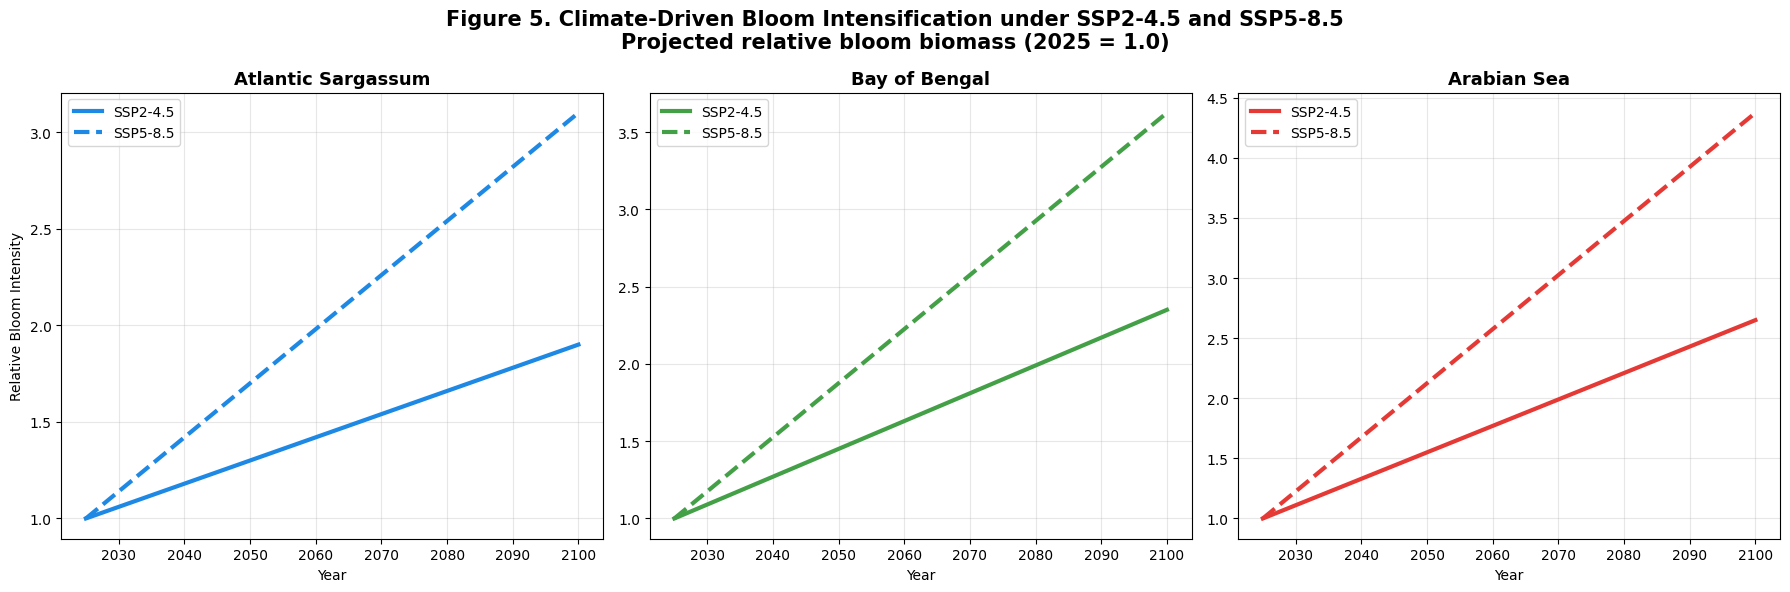

In [8]:
import numpy as np
import matplotlib.pyplot as plt

years = np.arange(2025, 2101)
# Simulated bloom intensity increase under two scenarios
atlantic_ssp245 = 1.0 + 0.012 * (years - 2025)
atlantic_ssp585 = 1.0 + 0.028 * (years - 2025)
bob_ssp245 = 1.0 + 0.018 * (years - 2025)
bob_ssp585 = 1.0 + 0.035 * (years - 2025)
arabian_ssp245 = 1.0 + 0.022 * (years - 2025)
arabian_ssp585 = 1.0 + 0.045 * (years - 2025)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 5. Climate-Driven Bloom Intensification under SSP2-4.5 and SSP5-8.5\nProjected relative bloom biomass (2025 = 1.0)', fontsize=15, fontweight='bold')

systems = ['Atlantic Sargassum', 'Bay of Bengal', 'Arabian Sea']
colors = ['#1E88E5', '#43A047', '#E53935']

for i, sys in enumerate(systems):
    ax = axs[i]
    ax.plot(years, locals()[f"{['atlantic','bob','arabian'][i]}_ssp245"], color=colors[i], linewidth=3, label='SSP2-4.5')
    ax.plot(years, locals()[f"{['atlantic','bob','arabian'][i]}_ssp585"], color=colors[i], linewidth=3, linestyle='--', label='SSP5-8.5')
    ax.set_title(sys, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Relative Bloom Intensity' if i == 0 else '')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('figures/Figure5_ClimateProjections.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure5_ClimateProjections.svg', format='svg', bbox_inches='tight')

print("✅ Figure 5 saved successfully!")
print("   - PNG (600 dpi): figures/Figure5_ClimateProjections.png")
print("   - SVG (editable): figures/Figure5_ClimateProjections.svg")
plt.show()

✅ Figure 6 saved successfully!
   - PNG (600 dpi): figures/Figure6_SustainableHarvesting_CircularBioeconomy.png
   - SVG (editable): figures/Figure6_SustainableHarvesting_CircularBioeconomy.svg


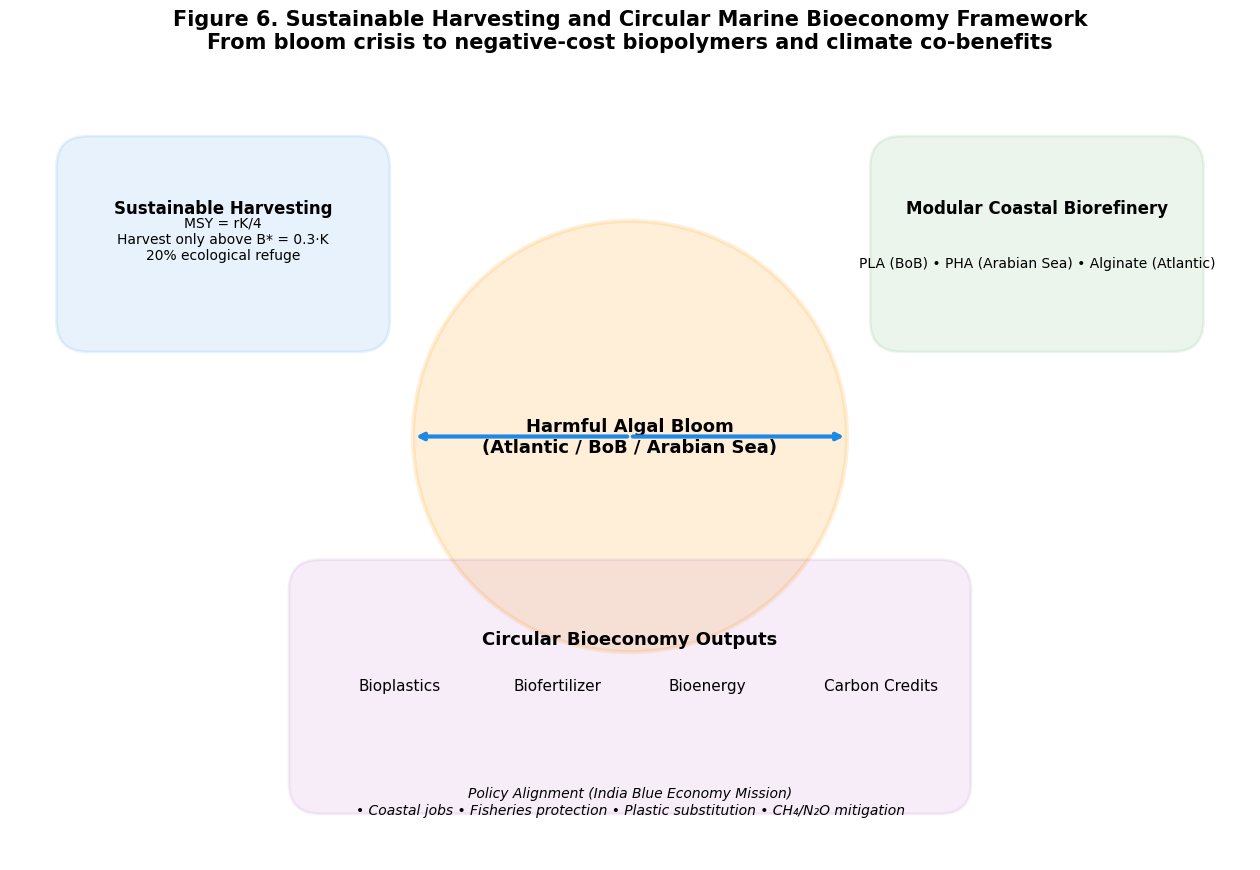

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, ArrowStyle

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

# Central bloom circle
ax.add_patch(Circle((8, 5.5), 2.8, facecolor='#FF9800', alpha=0.15, edgecolor='#FF9800', linewidth=3))
ax.text(8, 5.5, 'Harmful Algal Bloom\n(Atlantic / BoB / Arabian Sea)', ha='center', va='center', fontsize=13, fontweight='bold')

# Three harvesting arrows
ax.annotate('', xy=(5.2, 5.5), xytext=(8, 5.5), arrowprops=dict(arrowstyle='->', lw=3, color='#1E88E5'))
ax.annotate('', xy=(10.8, 5.5), xytext=(8, 5.5), arrowprops=dict(arrowstyle='->', lw=3, color='#1E88E5'))

# Sustainable harvesting box
ax.add_patch(FancyBboxPatch((1, 7), 3.5, 2, boxstyle="round,pad=0.4", facecolor='#1E88E5', alpha=0.1, edgecolor='#1E88E5', linewidth=2))
ax.text(2.75, 8.4, 'Sustainable Harvesting', ha='center', fontsize=12, fontweight='bold')
ax.text(2.75, 7.8, 'MSY = rK/4\nHarvest only above B* = 0.3·K\n20% ecological refuge', ha='center', fontsize=10)

# Biorefinery box
ax.add_patch(FancyBboxPatch((11.5, 7), 3.5, 2, boxstyle="round,pad=0.4", facecolor='#43A047', alpha=0.1, edgecolor='#43A047', linewidth=2))
ax.text(13.25, 8.4, 'Modular Coastal Biorefinery', ha='center', fontsize=12, fontweight='bold')
ax.text(13.25, 7.7, 'PLA (BoB) • PHA (Arabian Sea) • Alginate (Atlantic)', ha='center', fontsize=10)

# Circular loops
ax.add_patch(FancyBboxPatch((4, 1), 8, 2.5, boxstyle="round,pad=0.4", facecolor='#8E24AA', alpha=0.08, edgecolor='#8E24AA', linewidth=2))
ax.text(8, 2.8, 'Circular Bioeconomy Outputs', ha='center', fontsize=13, fontweight='bold')
ax.text(4.5, 2.2, 'Bioplastics', fontsize=11)
ax.text(6.5, 2.2, 'Biofertilizer', fontsize=11)
ax.text(8.5, 2.2, 'Bioenergy', fontsize=11)
ax.text(10.5, 2.2, 'Carbon Credits', fontsize=11)

# Policy & co-benefits
ax.text(8, 0.6, 'Policy Alignment (India Blue Economy Mission)\n• Coastal jobs • Fisheries protection • Plastic substitution • CH₄/N₂O mitigation',
        ha='center', fontsize=10, style='italic')

plt.title('Figure 6. Sustainable Harvesting and Circular Marine Bioeconomy Framework\nFrom bloom crisis to negative-cost biopolymers and climate co-benefits',
          fontsize=15, fontweight='bold', pad=30)

plt.savefig('figures/Figure6_SustainableHarvesting_CircularBioeconomy.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure6_SustainableHarvesting_CircularBioeconomy.svg', format='svg', bbox_inches='tight')

print("✅ Figure 6 saved successfully!")
print("   - PNG (600 dpi): figures/Figure6_SustainableHarvesting_CircularBioeconomy.png")
print("   - SVG (editable): figures/Figure6_SustainableHarvesting_CircularBioeconomy.svg")
plt.show()

✅ Improved Figure 6 saved successfully!
   - PNG (600 dpi): figures/Figure6_SustainableHarvesting_CircularBioeconomy.png
   - SVG (editable): figures/Figure6_SustainableHarvesting_CircularBioeconomy.svg


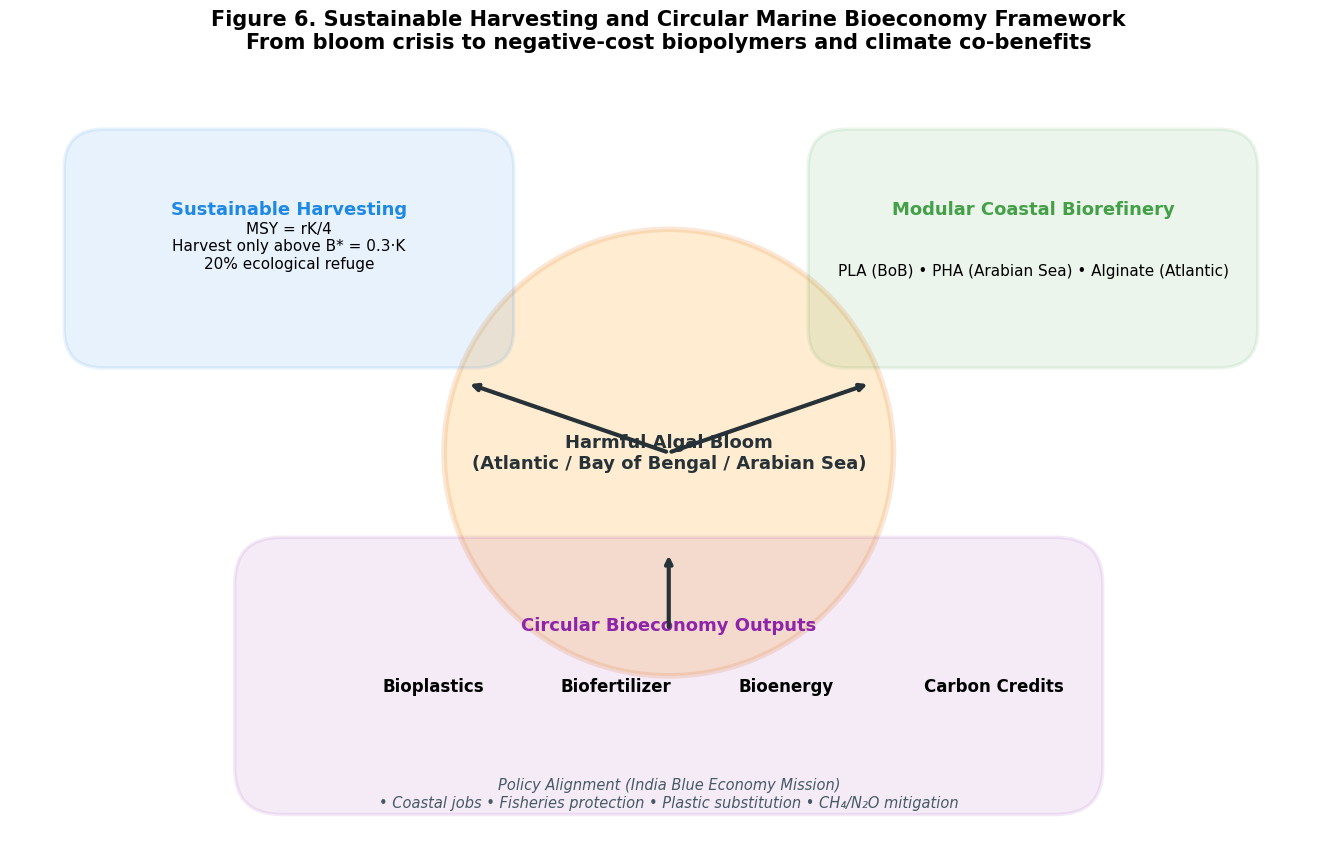

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle

fig, ax = plt.subplots(figsize=(17, 10))
ax.set_xlim(0, 17)
ax.set_ylim(0, 10)
ax.axis('off')

# Central bloom circle
ax.add_patch(Circle((8.5, 5.2), 2.9, facecolor='#FF9800', alpha=0.18, edgecolor='#E67E22', linewidth=4))
ax.text(8.5, 5.2, 'Harmful Algal Bloom\n(Atlantic / Bay of Bengal / Arabian Sea)',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#263238')

# Left box - Sustainable Harvesting
ax.add_patch(FancyBboxPatch((1.2, 6.8), 4.8, 2.1, boxstyle="round,pad=0.5", facecolor='#1E88E5', alpha=0.1, edgecolor='#1E88E5', linewidth=2.5))
ax.text(3.6, 8.3, 'Sustainable Harvesting', ha='center', fontsize=13, fontweight='bold', color='#1E88E5')
ax.text(3.6, 7.6, 'MSY = rK/4\nHarvest only above B* = 0.3·K\n20% ecological refuge', ha='center', fontsize=11)

# Right box - Modular Coastal Biorefinery
ax.add_patch(FancyBboxPatch((10.8, 6.8), 4.8, 2.1, boxstyle="round,pad=0.5", facecolor='#43A047', alpha=0.1, edgecolor='#43A047', linewidth=2.5))
ax.text(13.2, 8.3, 'Modular Coastal Biorefinery', ha='center', fontsize=13, fontweight='bold', color='#43A047')
ax.text(13.2, 7.5, 'PLA (BoB) • PHA (Arabian Sea) • Alginate (Atlantic)', ha='center', fontsize=11)

# Bottom box - Circular Bioeconomy Outputs
ax.add_patch(FancyBboxPatch((3.5, 1.1), 10, 2.4, boxstyle="round,pad=0.6", facecolor='#8E24AA', alpha=0.09, edgecolor='#8E24AA', linewidth=2.5))
ax.text(8.5, 2.9, 'Circular Bioeconomy Outputs', ha='center', fontsize=13, fontweight='bold', color='#8E24AA')
ax.text(4.8, 2.1, 'Bioplastics', fontsize=12, fontweight='bold')
ax.text(7.1, 2.1, 'Biofertilizer', fontsize=12, fontweight='bold')
ax.text(9.4, 2.1, 'Bioenergy', fontsize=12, fontweight='bold')
ax.text(11.8, 2.1, 'Carbon Credits', fontsize=12, fontweight='bold')

# Policy line at bottom
ax.text(8.5, 0.6, 'Policy Alignment (India Blue Economy Mission)\n• Coastal jobs • Fisheries protection • Plastic substitution • CH₄/N₂O mitigation',
        ha='center', fontsize=10.5, style='italic', color='#455A64')

# Connecting arrows
ax.annotate('', xy=(5.9, 6.1), xytext=(8.5, 5.2), arrowprops=dict(arrowstyle='->', lw=3, color='#263238'))
ax.annotate('', xy=(11.1, 6.1), xytext=(8.5, 5.2), arrowprops=dict(arrowstyle='->', lw=3, color='#263238'))
ax.annotate('', xy=(8.5, 3.9), xytext=(8.5, 2.9), arrowprops=dict(arrowstyle='->', lw=3, color='#263238'))

plt.title('Figure 6. Sustainable Harvesting and Circular Marine Bioeconomy Framework\nFrom bloom crisis to negative-cost biopolymers and climate co-benefits',
          fontsize=15, fontweight='bold', pad=25)

plt.savefig('figures/Figure6_SustainableHarvesting_CircularBioeconomy.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/Figure6_SustainableHarvesting_CircularBioeconomy.svg', format='svg', bbox_inches='tight')

print("✅ Improved Figure 6 saved successfully!")
print("   - PNG (600 dpi): figures/Figure6_SustainableHarvesting_CircularBioeconomy.png")
print("   - SVG (editable): figures/Figure6_SustainableHarvesting_CircularBioeconomy.svg")
plt.show()